In [1]:
#digit classification via mlp   

In [2]:
import torch 
import torch.nn as nn
import torchvision 
import torchvision.transforms as transfroms
import matplotlib.pyplot as plt

In [3]:
#deivce config
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)              

cpu


In [4]:
#hyper params
input_size = 28*28
hidden_size = 100
no_classes = 10
no_epochs = 10
batch_size = 100
lr = 0.001

In [5]:
#importing the data
train_dataset = torchvision.datasets.MNIST(
    root='./data', 
    train=True, 
    transform=transfroms.ToTensor(),
    download=True
    )

test_dataset = torchvision.datasets.MNIST(
    root='./data', 
    train= False, 
    transform=transfroms.ToTensor(),
    download=False
    )

In [6]:
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)


In [7]:
#having a look at 1 batch, as an example
#we create an iter object from dataloader

example = iter(train_loader)
samples, labels = next(example)

print(example)
print(type(samples), type(labels))

print(samples.shape, labels.shape)

#torch.Size([100, 1, 28, 28]) torch.Size([100])
# 100 - samples, 1 - color channel, 28*28


<class 'torch.Tensor'> <class 'torch.Tensor'>
torch.Size([100, 1, 28, 28]) torch.Size([100])


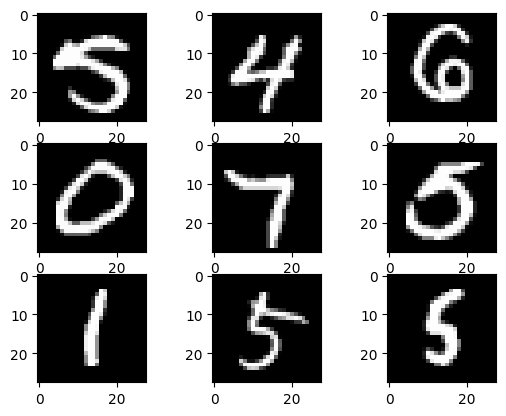

In [8]:
#Display image

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(samples[i][0], cmap='gray')

plt.show()

In [9]:
#Making the neural network

class NeuralNet(nn.Module):
    def __init__(self, input_size, hidden_size, no_classes):
        super(NeuralNet, self).__init__()
        self.l1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.l2 = nn.Linear(hidden_size, no_classes)

    def forward(self, x):
        out = self.l1(x)
        out = self.relu(out)
        out = self.l2(out)
        return out

In [10]:
model = NeuralNet(input_size, hidden_size, no_classes)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

In [11]:
#Training loop
for epoch in range(no_epochs):
    for i, (images, labels) in enumerate(train_loader):
        # 100,1,28,28 => 100,784
        images = images.reshape(-1, 28*28)

        #Forward
        output = model(images)
        loss = criterion(output, labels)

        #Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        print(f"epoch = {epoch+1}/{no_epochs}, loss = {loss.item():.4f}")


epoch = 1/10, loss = 2.3213
epoch = 1/10, loss = 2.2601
epoch = 1/10, loss = 2.2302
epoch = 1/10, loss = 2.1809
epoch = 1/10, loss = 2.1165
epoch = 1/10, loss = 2.1215
epoch = 1/10, loss = 2.0266
epoch = 1/10, loss = 2.0453
epoch = 1/10, loss = 1.9180
epoch = 1/10, loss = 1.9372
epoch = 1/10, loss = 1.8837
epoch = 1/10, loss = 1.8442
epoch = 1/10, loss = 1.7866
epoch = 1/10, loss = 1.7318
epoch = 1/10, loss = 1.6496
epoch = 1/10, loss = 1.5569
epoch = 1/10, loss = 1.6990
epoch = 1/10, loss = 1.6044
epoch = 1/10, loss = 1.4503
epoch = 1/10, loss = 1.4980
epoch = 1/10, loss = 1.4582
epoch = 1/10, loss = 1.3434
epoch = 1/10, loss = 1.2095
epoch = 1/10, loss = 1.2825
epoch = 1/10, loss = 1.2594
epoch = 1/10, loss = 1.2285
epoch = 1/10, loss = 1.2265
epoch = 1/10, loss = 1.0905
epoch = 1/10, loss = 1.0957
epoch = 1/10, loss = 1.0467
epoch = 1/10, loss = 1.1391
epoch = 1/10, loss = 1.0167
epoch = 1/10, loss = 0.9834
epoch = 1/10, loss = 0.9435
epoch = 1/10, loss = 0.9391
epoch = 1/10, loss =

In [12]:
#test
with torch.no_grad():
    n_samples=0
    n_correct=0
    for images, labels in test_loader:
        images = images.reshape(-1,28*28)
        output = model(images)

        _,pred = torch.max(output,1)
        n_samples+=labels.shape[0]
        n_correct=(pred==labels).sum().item()

    acc=100*n_correct/n_samples
    print('accuracy=', acc)




accuracy= 0.99
